# 04｜Process–Quality Relationship Analysis

---

## 這份 Notebook 要做什麼？

前面的結果已經告訴我兩件很重要的事：

- 02：**10 / 10 Lots 的 Mean Si Etch 都會隨 Wafer Sequence 下降**
- 03：**多個 Process Signals 也會隨 Lot 內的 Wafer Sequence 系統性變化**

所以這一份不能直接把全部 wafer 混在一起算：

`Process Signal ↔ Quality`

因為如果 Process 和 Quality 都只是一起跟著 `wafer_number` 變化，普通 pooled correlation 可能會看起來很高，但不代表兩者真的有獨立關係。

這份 Notebook 會直接使用：

- `02 → wafer_quality_summary.csv`
- `03 → process_wafer_summary.csv`

主要回答：

1. 96 片 Process wafers 和 88 片 Quality wafers 能不能正確一對一配對？
2. 如果直接算 pooled correlation，會看到哪些看起來很強的關係？
3. 在每個 Lot 內先移除 Process 和 Quality 對 Wafer Number 的線性 trend 後，哪些 residual associations 還存在？
4. Mean Si Etch 和 Within-Wafer CV 對應到的 Process pattern 是否一樣？
5. 目前只有 10 個 Lots，這些 sequence-adjusted associations 對 Lot composition 有多敏感？

這裡做的是 **sequence-aware exploratory association analysis**。

04 的主要 correlation 仍然是 exploratory ranking；新增的 **Lot-level cluster bootstrap** 只用來補 uncertainty，不會改寫 candidate-selection 規則，也不會把 correlation 解讀成因果關係。


## 1. 載入套件

這一份主要用到表格處理、統計 correlation 和畫圖。

因為 Main Active Window 已經在 03 建好，所以 04 不再讀 Raw NetCDF，也不會重新切 Process Window。


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 180)

print("套件載入完成")

套件載入完成


### 這個輸出代表什麼？

這格只顯示：

`套件載入完成`

代表這一格需要的 Python 套件都有成功載入，而且執行時沒有出現錯誤。這裡還沒有產生分析結果。


## 2. 設定 04 要使用的兩份正式輸入

04 只讀兩份上游結果：

### Quality
`wafer_quality_summary.csv`，來自 02

### Process
`process_wafer_summary.csv`，來自 03

這樣做的原因很單純：Main Active Window 已經在 03 定義完成，04 不需要再從 Raw NetCDF 重算一次。

也就是說，Quality 的定義由 02 負責，Process Window 的定義由 03 負責，04 只專心分析兩邊的 relationship。


In [2]:
def find_project_root(start=None):
    """Find the project root by walking upward from the current directory."""
    start = Path.cwd().resolve() if start is None else Path(start).resolve()

    for candidate in [start, *start.parents]:
        if (
            (candidate / "notebooks").exists()
            and (candidate / "data").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Project root not found. Expected a parent directory "
        "containing both notebooks/ and data/."
    )


CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = find_project_root(CURRENT_DIR)


PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

wafer_quality_path = (
    PROCESSED_DATA_DIR / "wafer_quality_summary.csv"
)
process_summary_path = (
    PROCESSED_DATA_DIR / "process_wafer_summary.csv"
)

required_paths = [
    wafer_quality_path,
    process_summary_path,
]

missing_paths = [
    path for path in required_paths
    if not path.exists()
]

assert not missing_paths, (
    "缺少必要上游 artifacts："
    + ", ".join(str(path) for path in missing_paths)
)

print("Quality Artifact：", wafer_quality_path)
print("Process Artifact：", process_summary_path)

Quality Artifact： C:\Users\momo8\Desktop\semiconductor-etch-process-intelligence\data\processed\wafer_quality_summary.csv
Process Artifact： C:\Users\momo8\Desktop\semiconductor-etch-process-intelligence\data\processed\process_wafer_summary.csv


### 這個輸出代表什麼？

這格顯示 04 會讀取兩個已經存在的上游檔案：

- `wafer_quality_summary.csv`
- `process_wafer_summary.csv`

兩個檔案都位在 `data/processed` 裡，而且這格有正常執行完成，沒有出現缺檔錯誤。


## 3. 載入後先檢查 02 / 03 的資料有沒有被改掉

正式做 correlation 前，我先做基本 integrity check。

### Quality 這邊要確認
- 88 rows
- 88 個 unique `experiment_key`
- 每片 wafer 有 89 個量測點

### Process 這邊要確認
- 96 rows
- 96 個 unique `experiment_key`
- 27 個 `main_mean__*` features
- 69 片 terminal-gap wafers
- Main Active Duration 大約落在 591.8–602.2 秒

這一段不是重做 02 / 03，只是確認資料傳到 04 時還是同一個版本。


In [3]:
wafer_quality_df = pd.read_csv(wafer_quality_path)
process_wafer_summary = pd.read_csv(process_summary_path)

required_quality_columns = {
    "experiment_key",
    "lot_number",
    "wafer_number",
    "n_points",
    "mean_si_etch",
    "cv_si_etch_pct",
}

required_process_columns = {
    "experiment_key",
    "lot_number",
    "wafer_number",
    "terminal_gap",
    "main_active_duration",
}

missing_quality = (
    required_quality_columns
    - set(wafer_quality_df.columns)
)
missing_process = (
    required_process_columns
    - set(process_wafer_summary.columns)
)

assert not missing_quality, (
    f"Quality artifact 缺少欄位：{sorted(missing_quality)}"
)
assert not missing_process, (
    f"Process artifact 缺少欄位：{sorted(missing_process)}"
)

main_mean_columns = [
    column
    for column in process_wafer_summary.columns
    if column.startswith("main_mean__")
]

assert len(wafer_quality_df) == 88
assert wafer_quality_df["experiment_key"].is_unique
assert wafer_quality_df["n_points"].eq(89).all()

assert len(process_wafer_summary) == 96
assert process_wafer_summary["experiment_key"].is_unique
assert len(main_mean_columns) == 27

terminal_gap_count = int(
    process_wafer_summary["terminal_gap"].sum()
)

assert terminal_gap_count == 69

print("Quality Wafers：", len(wafer_quality_df))
print("Process Wafers：", len(process_wafer_summary))
print("Main Mean Features：", len(main_mean_columns))
print("Terminal Gap Wafers：", terminal_gap_count)

display(
    wafer_quality_df[
        ["mean_si_etch", "cv_si_etch_pct"]
    ].describe().T
)

display(
    process_wafer_summary[
        ["main_active_duration"]
    ].describe().T
)

Quality Wafers： 88
Process Wafers： 96
Main Mean Features： 27
Terminal Gap Wafers： 69


,count,mean,std,min,25%,50%,75%,max
mean_si_etch,88.0,43.66812,0.401909,42.942928,43.349077,43.667601,43.983902,44.376304
cv_si_etch_pct,88.0,8.21143,0.182921,7.904162,8.092702,8.191840,8.309548,8.946925


,count,mean,std,min,25%,50%,75%,max
main_active_duration,96.0,597.542083,2.198244,591.8,597.1,598.0,598.0,602.2


### 這個輸出代表什麼？

這格先把 04 要用的資料數量和基本分布印出來。

目前實際讀到：

- Quality Wafers：**88 片**
- Process Wafers：**96 片**
- Main Mean Features：**27 個**
- Terminal Gap Wafers：**69 片**

Quality 的描述統計是：

- `mean_si_etch` 平均值 = **43.6681**
- 標準差 = **0.4019**
- 最小值 = **42.9429**
- 中位數 = **43.6676**
- 最大值 = **44.3763**

`cv_si_etch_pct` 的結果是：

- 平均值 = **8.2114%**
- 標準差 = **0.1829**
- 最小值 = **7.9042%**
- 中位數 = **8.1918%**
- 最大值 = **8.9469%**

`main_active_duration` 一共是 96 筆：

- 平均 = **597.5421 秒**
- 標準差 = **2.1982 秒**
- 最小值 = **591.8 秒**
- 中位數 = **598.0 秒**
- 最大值 = **602.2 秒**

這格就是把目前 04 實際讀到的資料量和主要欄位分布先列出來。


## 4. 把 Process Wafer 和 Quality Wafer 一對一配起來

這裡使用 `experiment_key` 做 one-to-one inner merge。

除了檢查數量，我也會確認：

- `lot_number` 是否完全一致
- `wafer_number` 是否完全一致

因為只看 key 能不能 merge 還不夠。如果 Lot 或 Wafer Number 對錯，後面算出的 correlation 也會跟著錯。


In [4]:
process_quality_df = pd.merge(
    process_wafer_summary,
    wafer_quality_df,
    on="experiment_key",
    how="inner",
    validate="one_to_one",
    suffixes=("_process", "_quality"),
)

process_only_keys = sorted(
    set(process_wafer_summary["experiment_key"])
    - set(wafer_quality_df["experiment_key"])
)

quality_only_keys = sorted(
    set(wafer_quality_df["experiment_key"])
    - set(process_wafer_summary["experiment_key"])
)

lot_match = (
    process_quality_df["lot_number_process"]
    .eq(process_quality_df["lot_number_quality"])
    .all()
)

wafer_number_match = (
    process_quality_df["wafer_number_process"]
    .eq(process_quality_df["wafer_number_quality"])
    .all()
)

assert len(process_quality_df) == 88
assert len(process_only_keys) == 8
assert len(quality_only_keys) == 0
assert lot_match
assert wafer_number_match

process_quality_df["lot_number"] = (
    process_quality_df["lot_number_process"].astype(int)
)

process_quality_df["wafer_number"] = (
    process_quality_df["wafer_number_process"].astype(int)
)

print("Process Wafers：", len(process_wafer_summary))
print("Quality Wafers：", len(wafer_quality_df))
print("Matched Wafers：", len(process_quality_df))
print("Process-only Wafers：", len(process_only_keys))
print("Quality-only Wafers：", len(quality_only_keys))
print("Lot Number 完全一致：", lot_match)
print("Wafer Number 完全一致：", wafer_number_match)

print("\n沒有 89-point Quality Outcome 的 Process Wafers：")
for key in process_only_keys:
    print("-", key)

Process Wafers： 96
Quality Wafers： 88
Matched Wafers： 88
Process-only Wafers： 8
Quality-only Wafers： 0
Lot Number 完全一致： True
Wafer Number 完全一致： True

沒有 89-point Quality Outcome 的 Process Wafers：
- 2024-07-02_07
- 2024-08-21_09
- 2024-08-22_05
- 2024-08-22_06
- 2024-08-22_07
- 2024-08-22_08
- 2024-08-22_09
- 2024-08-22_10


### 這個輸出代表什麼？

Process 資料原本有 **96 片 wafer**，Quality 資料有 **88 片 wafer**。

用 `experiment_key` 配對後：

- 成功配對：**88 片**
- 只有 Process、沒有 Quality：**8 片**
- 只有 Quality、沒有 Process：**0 片**
- Lot Number 是否全部一致：**True**
- Wafer Number 是否全部一致：**True**

沒有 89-point Quality Outcome 的 8 片 Process wafers 是：

- `2024-07-02_07`
- `2024-08-21_09`
- `2024-08-22_05`
- `2024-08-22_06`
- `2024-08-22_07`
- `2024-08-22_08`
- `2024-08-22_09`
- `2024-08-22_10`

所以這格實際顯示的是：04 有 **88 片同時有 Process 和 Quality 的 wafers** 可以拿來做後面的 relationship analysis。


## 5. 看 88 片 Matched Wafers 分布在哪些 Lots

不同 Lot 有 Quality outcome 的 wafer 數量不完全一樣。

這件事會影響：

- 每個 Lot 內 correlation 的穩定度
- pooled residual correlation 中各 Lot 實際貢獻的 observation 數

所以在正式算 relationship 前，我先把每個 Lot 的 matched sample size 列出來。


In [5]:
matched_wafers_by_lot = (
    process_quality_df
    .groupby("lot_number")
    .agg(
        n_matched_wafers=("experiment_key", "nunique"),
        first_wafer=("wafer_number", "min"),
        last_wafer=("wafer_number", "max"),
    )
    .reset_index()
)

matched_wafers_by_lot

,lot_number,n_matched_wafers,first_wafer,last_wafer
0,1,9,1,10
1,2,10,1,10
2,3,10,1,10
3,4,10,1,10
4,5,10,1,10
5,6,10,1,10
6,7,6,1,6
7,8,10,1,10
8,9,9,1,10
9,10,4,1,4


### 這個輸出代表什麼？

88 片 matched wafers 分布在 10 個 Lots：

- Lot 1：**9 片**，Wafer Number 1～10
- Lot 2：**10 片**，1～10
- Lot 3：**10 片**，1～10
- Lot 4：**10 片**，1～10
- Lot 5：**10 片**，1～10
- Lot 6：**10 片**，1～10
- Lot 7：**6 片**，1～6
- Lot 8：**10 片**，1～10
- Lot 9：**9 片**，1～10
- Lot 10：**4 片**，1～4

這格主要就是把每個 Lot 實際有多少 matched wafers 列清楚。


# Part A｜Sequence-Aware Relationship Method

## 6. 為什麼不能只看普通 Pooled Correlation？

前面的資料結構是：

`Wafer Number → Mean Si Etch`

而且同時也有：

`Wafer Number → 多個 Process Signals`

所以 04 會同時計算三種 relationship。

### 1. Pooled Correlation
直接把 88 片 matched wafers 放在一起算。

### 2. Median Within-Lot Spearman
每個 Lot 分開算 Spearman，再把有效 Lots 的結果取中位數。

### 3. Lot-Specific Linear Sequence-Adjusted Correlation
每個 Lot 內分別做：

`Process Feature ~ Wafer Number`

`Quality Outcome ~ Wafer Number`

接著把兩邊 residual 合併，再算 Pearson / Spearman。

直觀來說，就是先把每個 Lot 自己的 baseline 和簡單線性 wafer-sequence trend 扣掉，再看「偏離各自 trend 的部分」是不是還會一起變。

需要注意的是，這仍然不是 causal analysis。它只能移除目前明確處理的 linear sequence structure，不能保證排除非線性 sequence、chamber state 或其他 confounders。


In [6]:
def is_effectively_constant(values):
    values = np.asarray(values, dtype=float)

    if len(values) == 0:
        return True

    return np.allclose(
        values,
        values[0],
        rtol=1e-7,
        atol=1e-8,
    )


def detrend_within_lot(
    dataframe,
    value_column,
):
    residuals = pd.Series(
        index=dataframe.index,
        dtype=float,
    )

    for _, group in dataframe.groupby("lot_number"):
        x = group["wafer_number"].to_numpy(dtype=float)
        y = group[value_column].to_numpy(dtype=float)

        slope, intercept = np.polyfit(x, y, deg=1)
        predicted = intercept + slope * x

        residuals.loc[group.index] = y - predicted

    return residuals.sort_index().to_numpy(dtype=float)


def safe_correlation(
    x,
    y,
    method="pearson",
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if is_effectively_constant(x) or is_effectively_constant(y):
        return np.nan

    if method == "pearson":
        return float(pearsonr(x, y).statistic)

    if method == "spearman":
        return float(spearmanr(x, y).statistic)

    raise ValueError("method 必須是 pearson 或 spearman")


def analyze_process_quality_relationship(
    dataframe,
    outcome_column,
):
    result_records = []

    outcome_values = dataframe[
        outcome_column
    ].to_numpy(dtype=float)

    outcome_residuals = detrend_within_lot(
        dataframe,
        outcome_column,
    )

    for process_column in main_mean_columns:
        feature_name = process_column.replace(
            "main_mean__",
            "",
        )

        feature_values = dataframe[
            process_column
        ].to_numpy(dtype=float)

        pooled_pearson = safe_correlation(
            feature_values,
            outcome_values,
            method="pearson",
        )

        pooled_spearman = safe_correlation(
            feature_values,
            outcome_values,
            method="spearman",
        )

        within_lot_spearman = []

        for _, group in dataframe.groupby("lot_number"):
            x = group[
                process_column
            ].to_numpy(dtype=float)

            y = group[
                outcome_column
            ].to_numpy(dtype=float)

            if len(group) < 3:
                continue

            correlation = safe_correlation(
                x,
                y,
                method="spearman",
            )

            if np.isfinite(correlation):
                within_lot_spearman.append(correlation)

        feature_residuals = detrend_within_lot(
            dataframe,
            process_column,
        )

        residual_tolerance = (
            1e-8
            + 1e-7
            * np.nanmax(np.abs(feature_values))
        )

        if (
            np.nanstd(feature_residuals)
            <= residual_tolerance
        ):
            adjusted_pearson = np.nan
            adjusted_spearman = np.nan
        else:
            adjusted_pearson = safe_correlation(
                feature_residuals,
                outcome_residuals,
                method="pearson",
            )

            adjusted_spearman = safe_correlation(
                feature_residuals,
                outcome_residuals,
                method="spearman",
            )

        result_records.append(
            {
                "feature": feature_name,
                "pooled_pearson": pooled_pearson,
                "pooled_spearman": pooled_spearman,
                "median_within_lot_spearman": (
                    float(np.nanmedian(within_lot_spearman))
                    if within_lot_spearman
                    else np.nan
                ),
                "n_valid_lots": len(within_lot_spearman),
                "sequence_adjusted_pearson": adjusted_pearson,
                "sequence_adjusted_spearman": adjusted_spearman,
            }
        )

    result_df = pd.DataFrame(result_records)

    result_df["abs_sequence_adjusted_pearson"] = (
        result_df[
            "sequence_adjusted_pearson"
        ].abs()
    )

    return (
        result_df
        .sort_values(
            "abs_sequence_adjusted_pearson",
            ascending=False,
            na_position="last",
        )
        .reset_index(drop=True)
    )


print("Relationship functions 建立完成")

Relationship functions 建立完成


### 這個輸出代表什麼？

這格只輸出：

`Relationship functions 建立完成`

代表後面要用的 relationship 計算函式都有成功建立，而且這格執行時沒有錯誤。

這裡本身還沒有產生 correlation 結果。


# Part B｜Primary Outcome：Mean Si Etch

## 7. 計算 27 個 Process Features 和 Mean Si Etch 的 Relationship

這裡先把 27 個 features 全部放進同一套計算，建立完整 relationship table。

後面再分開看：

- pooled correlation 最強的 features
- sequence-adjusted correlation 最強的 features

這樣可以直接比較「沒有處理 sequence」和「處理後」到底差多少。


In [7]:
mean_etch_relationship = (
    analyze_process_quality_relationship(
        process_quality_df,
        "mean_si_etch",
    )
)

assert len(mean_etch_relationship) == 27

print("Process Features：", len(mean_etch_relationship))

mean_etch_relationship.round(4)

Process Features： 27


,feature,pooled_pearson,pooled_spearman,median_within_lot_spearman,n_valid_lots,sequence_adjusted_pearson,sequence_adjusted_spearman,abs_sequence_adjusted_pearson
0,Stat3_Etch_MV_PlatenRFLoadPower,-0.1076,-0.1303,-0.0242,10,-0.6090,-0.4855,0.6090
1,Stat3_Etch_MV_SourceRF2TuningCapacitor,-0.1836,-0.1820,-0.1741,5,-0.4333,-0.3324,0.4333
2,Stat3_Etch_MV_HeliumBPPressure,-0.3490,-0.3290,-0.2780,10,-0.3999,-0.4042,0.3999
3,Stat3_Etch_MV_Gas1Flow,0.0787,-0.0428,-0.1697,10,0.3298,0.1753,0.3298
4,Stat3_Etch_MV_PlatenRFPeakToPeak,-0.6845,-0.7147,-0.8121,10,-0.3290,-0.3128,0.3290
5,Stat3_Etch_MV_Pressure,-0.0297,-0.0012,-0.3030,10,-0.3079,-0.2382,0.3079
6,Stat3_Etch_MV_SourceRFReflectedPower,-0.5445,-0.5531,-0.5833,10,-0.2835,-0.3480,0.2835
7,Stat3_Etch_MV_Heater3Temp,-0.3132,-0.3321,-0.4714,10,-0.2594,-0.3019,0.2594
8,Stat3_Etch_MV_PlatenRFLoadCapacitor,0.1594,0.1678,0.3463,10,0.2315,0.2695,0.2315
9,Stat3_Etch_MV_PlatenDcBias,0.1536,0.2246,0.2045,10,-0.2242,-0.1858,0.2242


### 這個輸出代表什麼？

這張表一共列出 **27 個 Process Features** 和 `mean_si_etch` 的 relationship 結果。

目前 `sequence_adjusted_pearson` 絕對值比較大的幾個是：

- `PlatenRFLoadPower`：**-0.6090**
- `SourceRF2TuningCapacitor`：**-0.4333**
- `HeliumBPPressure`：**-0.3999**
- `Gas1Flow`：**+0.3298**
- `PlatenRFPeakToPeak`：**-0.3290**
- `Pressure`：**-0.3079**

其中 `SourceRF2TuningCapacitor` 的 `n_valid_lots` 只有 **5**，其他上面列出的 features 是 **10**。

表格最後兩個 features：

- `EpdIntensity`
- `SourceRFTuningCapacitor`

它們的 pooled correlation 和 sequence-adjusted correlation 都是 `NaN`，而且 `n_valid_lots = 0`。

這格主要就是把 27 個 features 的 pooled、within-lot 和 sequence-adjusted correlation 全部放在同一張表裡。


## 8. 先看如果完全不處理 Sequence，Pooled Correlation 會得到什麼

這一段故意先用最直接的 pooled correlation 排序。

我不是要把它當最後結論，而是想看：如果忽略 02、03 已經看到的 wafer-sequence structure，哪些 features 會看起來和 Mean Si Etch 很相關。


In [8]:
mean_etch_pooled_top = (
    mean_etch_relationship
    .assign(
        abs_pooled_pearson=lambda x:
            x["pooled_pearson"].abs()
    )
    .sort_values(
        "abs_pooled_pearson",
        ascending=False,
        na_position="last",
    )
    .head(10)
)

mean_etch_pooled_top[
    [
        "feature",
        "pooled_pearson",
        "pooled_spearman",
        "median_within_lot_spearman",
        "sequence_adjusted_pearson",
        "sequence_adjusted_spearman",
        "n_valid_lots",
    ]
].round(4)

,feature,pooled_pearson,pooled_spearman,median_within_lot_spearman,sequence_adjusted_pearson,sequence_adjusted_spearman,n_valid_lots
14,Stat3_Etch_MV_PlatenRFTuningCapacitor,-0.7593,-0.7644,-0.8545,-0.1415,-0.1477,10
4,Stat3_Etch_MV_PlatenRFPeakToPeak,-0.6845,-0.7147,-0.8121,-0.3290,-0.3128,10
6,Stat3_Etch_MV_SourceRFReflectedPower,-0.5445,-0.5531,-0.5833,-0.2835,-0.3480,10
23,Stat3_Etch_MV_moriInnerCurrent,-0.4393,-0.3969,-0.2545,0.0074,0.0401,10
11,Stat3_Etch_MV_SourceRFLoadPower,0.4282,0.4676,0.6879,-0.1774,-0.1205,10
2,Stat3_Etch_MV_HeliumBPPressure,-0.3490,-0.3290,-0.2780,-0.3999,-0.4042,10
7,Stat3_Etch_MV_Heater3Temp,-0.3132,-0.3321,-0.4714,-0.2594,-0.3019,10
13,Stat3_Etch_MV_Gas7Flow,-0.2615,-0.1852,-0.4629,-0.1481,-0.1776,10
10,Stat3_Etch_MV_Heater1Temp,-0.2185,-0.1935,-0.2985,-0.1859,-0.1904,10
1,Stat3_Etch_MV_SourceRF2TuningCapacitor,-0.1836,-0.1820,-0.1741,-0.4333,-0.3324,5


### 這個輸出代表什麼？

這張表是按照 `pooled_pearson` 絕對值挑出前 10 個 features。

Pooled Pearson 比較大的結果是：

- `PlatenRFTuningCapacitor`：**-0.7593**
- `PlatenRFPeakToPeak`：**-0.6845**
- `SourceRFReflectedPower`：**-0.5445**
- `moriInnerCurrent`：**-0.4393**
- `SourceRFLoadPower`：**+0.4282**
- `HeliumBPPressure`：**-0.3490**
- `Heater3Temp`：**-0.3132**
- `Gas7Flow`：**-0.2615**
- `Heater1Temp`：**-0.2185**
- `SourceRF2TuningCapacitor`：**-0.1836**

同一張表也可以直接看到 adjustment 後的數值有明顯變化。

例如：

- `PlatenRFTuningCapacitor`：**-0.7593 → -0.1415**
- `moriInnerCurrent`：**-0.4393 → +0.0074**
- `SourceRFLoadPower`：**+0.4282 → -0.1774**
- `HeliumBPPressure`：**-0.3490 → -0.3999**

所以這個輸出很直接地顯示，同一個 feature 在 pooled 和 sequence-adjusted 結果下，數值可能差很多。


## 9. 扣除 Lot-Specific Linear Sequence 後，再看 Mean Si Etch Relationship

接下來正式用 `abs(sequence_adjusted_pearson)` 排序，看哪些 relationship 在扣掉簡單 wafer-sequence trend 後仍然比較明顯。

同時保留：

- `median_within_lot_spearman`
- `n_valid_lots`

其中 `n_valid_lots` 只表示有多少 Lots 有足夠 variation 可以計算，不代表那些 Lots 的 correlation 方向全部一致。


In [9]:
mean_etch_adjusted_top = (
    mean_etch_relationship
    .head(12)
    .copy()
)

mean_etch_adjusted_top[
    [
        "feature",
        "pooled_pearson",
        "median_within_lot_spearman",
        "n_valid_lots",
        "sequence_adjusted_pearson",
        "sequence_adjusted_spearman",
    ]
].round(4)

,feature,pooled_pearson,median_within_lot_spearman,n_valid_lots,sequence_adjusted_pearson,sequence_adjusted_spearman
0,Stat3_Etch_MV_PlatenRFLoadPower,-0.1076,-0.0242,10,-0.6090,-0.4855
1,Stat3_Etch_MV_SourceRF2TuningCapacitor,-0.1836,-0.1741,5,-0.4333,-0.3324
2,Stat3_Etch_MV_HeliumBPPressure,-0.3490,-0.2780,10,-0.3999,-0.4042
3,Stat3_Etch_MV_Gas1Flow,0.0787,-0.1697,10,0.3298,0.1753
4,Stat3_Etch_MV_PlatenRFPeakToPeak,-0.6845,-0.8121,10,-0.3290,-0.3128
5,Stat3_Etch_MV_Pressure,-0.0297,-0.3030,10,-0.3079,-0.2382
6,Stat3_Etch_MV_SourceRFReflectedPower,-0.5445,-0.5833,10,-0.2835,-0.3480
7,Stat3_Etch_MV_Heater3Temp,-0.3132,-0.4714,10,-0.2594,-0.3019
8,Stat3_Etch_MV_PlatenRFLoadCapacitor,0.1594,0.3463,10,0.2315,0.2695
9,Stat3_Etch_MV_PlatenDcBias,0.1536,0.2045,10,-0.2242,-0.1858


### 這個輸出代表什麼？

這張表是 `sequence_adjusted_pearson` 絕對值較大的前 12 個結果。

實際數值是：

- `PlatenRFLoadPower`：Pearson **-0.6090**，Spearman **-0.4855**
- `SourceRF2TuningCapacitor`：Pearson **-0.4333**，Spearman **-0.3324**，`n_valid_lots = 5`
- `HeliumBPPressure`：Pearson **-0.3999**，Spearman **-0.4042**
- `Gas1Flow`：Pearson **+0.3298**，Spearman **+0.1753**
- `PlatenRFPeakToPeak`：Pearson **-0.3290**，Spearman **-0.3128**
- `Pressure`：Pearson **-0.3079**，Spearman **-0.2382**
- `SourceRFReflectedPower`：Pearson **-0.2835**，Spearman **-0.3480**
- `Heater3Temp`：Pearson **-0.2594**，Spearman **-0.3019**
- `PlatenRFLoadCapacitor`：Pearson **+0.2315**，Spearman **+0.2695**
- `PlatenDcBias`：Pearson **-0.2242**，Spearman **-0.1858**
- `Heater1Temp`：Pearson **-0.1859**，Spearman **-0.1904**
- `SourceRFLoadPower`：Pearson **-0.1774**，Spearman **-0.1205**

這格就是把 adjustment 後目前數值比較大的 features 按順序列出來。


## 10. 畫圖比較 Pooled Pearson 和 Sequence-Adjusted Pearson

這張圖把每個 feature 的 pooled Pearson 放在 X 軸，sequence-adjusted Pearson 放在 Y 軸。

如果某個點接近 `y = x`，代表 adjustment 前後變化不大。

如果離對角線很遠，代表這個 feature 的原始 correlation 對 Lot / Sequence adjustment 很敏感。

所以這張圖不是 feature ranking，而是直接看「調整前後改了多少」。


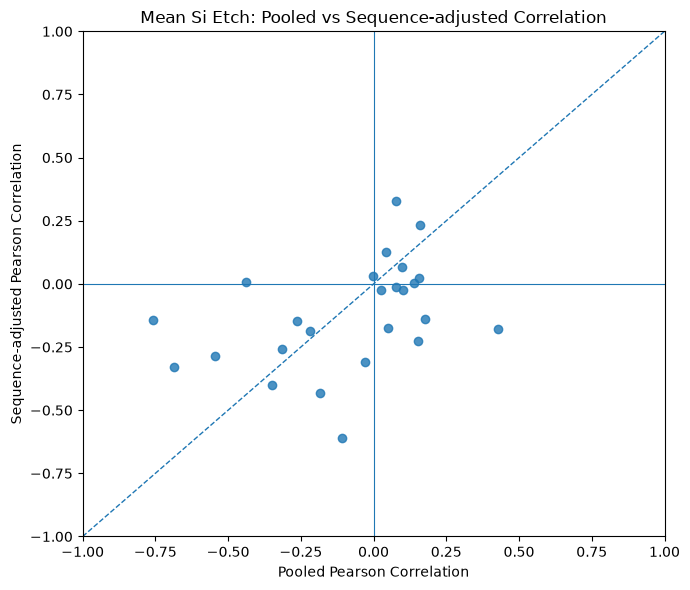

In [10]:
plot_df = (
    mean_etch_relationship
    .dropna(
        subset=[
            "pooled_pearson",
            "sequence_adjusted_pearson",
        ]
    )
)

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    plot_df["pooled_pearson"],
    plot_df["sequence_adjusted_pearson"],
    alpha=0.8,
)

limits = [-1, 1]

ax.plot(
    limits,
    limits,
    linestyle="--",
    linewidth=1,
)

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

ax.set_xlim(limits)
ax.set_ylim(limits)
ax.set_xlabel("Pooled Pearson Correlation")
ax.set_ylabel("Sequence-adjusted Pearson Correlation")
ax.set_title(
    "Mean Si Etch: Pooled vs Sequence-adjusted Correlation"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "process_quality_pooled_vs_adjusted.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 這張圖的輸出代表什麼？

圖上的 X 軸是 `Pooled Pearson Correlation`，Y 軸是 `Sequence-adjusted Pearson Correlation`。

虛線代表 X 和 Y 完全一樣的位置。

從圖上的點可以看到，不少 features 沒有落在虛線附近，也就是 adjustment 前後的 correlation 有明顯差別。

幾個比較明顯的例子是：

- `PlatenRFTuningCapacitor`：**-0.7593 → -0.1415**
- `SourceRFLoadPower`：**+0.4282 → -0.1774**
- `PlatenRFLoadPower`：**-0.1076 → -0.6090**
- `moriInnerCurrent`：**-0.4393 → +0.0074**

所以這張圖主要就是把每個 feature 在 adjustment 前後的 correlation 差異直接畫出來。


# Part C｜Secondary Outcome：Within-Wafer Relative Variation

## 11. 改看 `cv_si_etch_pct`

除了 Mean Si Etch，我也用相同方法分析 `cv_si_etch_pct`。

這個 CV 是用 89-point Si Etch 算出的描述性相對變異指標，用來看 wafer 內量測值的相對分散程度。它不是 dataset provider 提供的正式 manufacturing uniformity specification。

分析方法完全沿用前面的 sequence adjustment，避免兩個 outcomes 使用不同規則。


In [11]:
cv_relationship = (
    analyze_process_quality_relationship(
        process_quality_df,
        "cv_si_etch_pct",
    )
)

assert len(cv_relationship) == 27

cv_relationship.head(12)[
    [
        "feature",
        "pooled_pearson",
        "median_within_lot_spearman",
        "n_valid_lots",
        "sequence_adjusted_pearson",
        "sequence_adjusted_spearman",
    ]
].round(4)

,feature,pooled_pearson,median_within_lot_spearman,n_valid_lots,sequence_adjusted_pearson,sequence_adjusted_spearman
0,Stat3_Etch_MV_Heater4Temp,-0.3256,-0.1167,10,0.5513,0.4654
1,Stat3_Etch_MV_moriInnerCurrent,-0.5728,-0.5879,10,-0.5008,-0.5020
2,Stat3_Etch_MV_Gas7Flow,-0.2436,-0.7190,10,-0.4201,-0.5653
3,Stat3_Etch_MV_PlatenRFTuningCapacitor,-0.4875,-0.7939,10,-0.4107,-0.6259
4,Stat3_Etch_MV_PlatenRFPeakToPeak,-0.4748,-0.6864,10,-0.4088,-0.5157
5,Stat3_Etch_MV_Gas2Flow,0.4600,0.1818,10,0.3277,0.2363
6,Stat3_Etch_MV_Heater2Temp,0.5418,0.4326,10,0.3158,0.2005
7,Stat3_Etch_MV_PlatenDcBias,0.2137,0.1379,10,-0.2884,-0.3274
8,Stat3_Etch_MV_ForeLinePressure,0.2953,0.6545,10,0.2486,0.3489
9,Stat3_Etch_MV_Heater3Temp,-0.2219,-0.2303,10,-0.2340,-0.3674


### 這個輸出代表什麼？

這張表顯示的是 `cv_si_etch_pct` 的 relationship 結果，畫面上列出 sequence-adjusted Pearson 絕對值較大的前 12 個。

實際結果是：

- `Heater4Temp`：Pearson **+0.5513**，Spearman **+0.4654**
- `moriInnerCurrent`：Pearson **-0.5008**，Spearman **-0.5020**
- `Gas7Flow`：Pearson **-0.4201**，Spearman **-0.5653**
- `PlatenRFTuningCapacitor`：Pearson **-0.4107**，Spearman **-0.6259**
- `PlatenRFPeakToPeak`：Pearson **-0.4088**，Spearman **-0.5157**
- `Gas2Flow`：Pearson **+0.3277**，Spearman **+0.2363**
- `Heater2Temp`：Pearson **+0.3158**，Spearman **+0.2005**
- `PlatenDcBias`：Pearson **-0.2884**，Spearman **-0.3274**
- `ForeLinePressure`：Pearson **+0.2486**，Spearman **+0.3489**
- `Heater3Temp`：Pearson **-0.2340**，Spearman **-0.3674**
- `Gas4Flow`：Pearson **+0.1631**，Spearman **-0.0085**
- `HeliumBPPressure`：Pearson **-0.1622**，Spearman **-0.1748**

其中 `Heater4Temp` 的 pooled Pearson 是 **-0.3256**，sequence-adjusted Pearson 變成 **+0.5513**，是這張表裡方向變化很明顯的一個結果。

這格就是把 CV 對應的 sequence-adjusted relationship 數值列出來。


# Part D｜Exploratory Candidate Tables

## 12. 用固定規則整理一份比較短的候選清單

為了讓後面比較好追，我先用一個簡單的 exploratory rule：

- `abs(sequence_adjusted_pearson) >= 0.30`
- `n_valid_lots >= 8`

這個門檻只是用來縮小後續人工檢查範圍。

它不是：

- p-value threshold
- causal selection
- final ML feature selection

所以沒有通過門檻的 feature 也不能直接說「沒用」。


In [12]:
CANDIDATE_ABS_CORR_THRESHOLD = 0.30
CANDIDATE_MIN_VALID_LOTS = 8

mean_etch_candidates = (
    mean_etch_relationship
    .loc[
        (
            mean_etch_relationship[
                "abs_sequence_adjusted_pearson"
            ]
            >= CANDIDATE_ABS_CORR_THRESHOLD
        )
        &
        (
            mean_etch_relationship[
                "n_valid_lots"
            ]
            >= CANDIDATE_MIN_VALID_LOTS
        )
    ]
    .copy()
)

cv_candidates = (
    cv_relationship
    .loc[
        (
            cv_relationship[
                "abs_sequence_adjusted_pearson"
            ]
            >= CANDIDATE_ABS_CORR_THRESHOLD
        )
        &
        (
            cv_relationship[
                "n_valid_lots"
            ]
            >= CANDIDATE_MIN_VALID_LOTS
        )
    ]
    .copy()
)

print(
    "Mean Si Etch exploratory candidates：",
    len(mean_etch_candidates),
)

display(
    mean_etch_candidates[
        [
            "feature",
            "n_valid_lots",
            "sequence_adjusted_pearson",
            "sequence_adjusted_spearman",
        ]
    ].round(4)
)

print(
    "\nCV exploratory candidates：",
    len(cv_candidates),
)

display(
    cv_candidates[
        [
            "feature",
            "n_valid_lots",
            "sequence_adjusted_pearson",
            "sequence_adjusted_spearman",
        ]
    ].round(4)
)

Mean Si Etch exploratory candidates： 5


,feature,n_valid_lots,sequence_adjusted_pearson,sequence_adjusted_spearman
0,Stat3_Etch_MV_PlatenRFLoadPower,10,-0.6090,-0.4855
2,Stat3_Etch_MV_HeliumBPPressure,10,-0.3999,-0.4042
3,Stat3_Etch_MV_Gas1Flow,10,0.3298,0.1753
4,Stat3_Etch_MV_PlatenRFPeakToPeak,10,-0.3290,-0.3128
5,Stat3_Etch_MV_Pressure,10,-0.3079,-0.2382



CV exploratory candidates： 7


,feature,n_valid_lots,sequence_adjusted_pearson,sequence_adjusted_spearman
0,Stat3_Etch_MV_Heater4Temp,10,0.5513,0.4654
1,Stat3_Etch_MV_moriInnerCurrent,10,-0.5008,-0.5020
2,Stat3_Etch_MV_Gas7Flow,10,-0.4201,-0.5653
3,Stat3_Etch_MV_PlatenRFTuningCapacitor,10,-0.4107,-0.6259
4,Stat3_Etch_MV_PlatenRFPeakToPeak,10,-0.4088,-0.5157
5,Stat3_Etch_MV_Gas2Flow,10,0.3277,0.2363
6,Stat3_Etch_MV_Heater2Temp,10,0.3158,0.2005


### 這個輸出代表什麼？

依照這格設定的篩選條件，最後輸出：

- Mean Si Etch exploratory candidates：**5 個**
- CV exploratory candidates：**7 個**

Mean Si Etch 的 5 個是：

- `PlatenRFLoadPower`：Pearson **-0.6090**，Spearman **-0.4855**
- `HeliumBPPressure`：Pearson **-0.3999**，Spearman **-0.4042**
- `Gas1Flow`：Pearson **+0.3298**，Spearman **+0.1753**
- `PlatenRFPeakToPeak`：Pearson **-0.3290**，Spearman **-0.3128**
- `Pressure`：Pearson **-0.3079**，Spearman **-0.2382**

這 5 個的 `n_valid_lots` 都是 **10**。

CV 的 7 個是：

- `Heater4Temp`：Pearson **+0.5513**，Spearman **+0.4654**
- `moriInnerCurrent`：Pearson **-0.5008**，Spearman **-0.5020**
- `Gas7Flow`：Pearson **-0.4201**，Spearman **-0.5653**
- `PlatenRFTuningCapacitor`：Pearson **-0.4107**，Spearman **-0.6259**
- `PlatenRFPeakToPeak`：Pearson **-0.4088**，Spearman **-0.5157**
- `Gas2Flow`：Pearson **+0.3277**，Spearman **+0.2363**
- `Heater2Temp`：Pearson **+0.3158**，Spearman **+0.2005**

這 7 個的 `n_valid_lots` 也全部都是 **10**。

這格就是把符合目前篩選條件的兩組 candidate 清單直接列出來。


# Part E｜Lot-Level Bootstrap Uncertainty

## 13. 用 Lot-Level Cluster Bootstrap 補上 Association Uncertainty

前面的 candidate rule 是：

- `abs(sequence_adjusted_pearson) >= 0.30`
- `n_valid_lots >= 8`

這可以幫我整理出值得人工追蹤的 features，但單一 correlation 數字還不能回答：

> **這個 association 是不是只因為某幾個 Lots 剛好很強？**

目前只有 **10 個 Lots**，而且同一個 Lot 裡的 wafers 不是彼此完全獨立，所以這裡不能把 88 片 wafers 當成 88 個獨立單位做一般 row-level bootstrap。

因此這裡改用 **Lot-level cluster bootstrap**：

1. 先用和前面完全相同的方法，在每個 Lot 內扣掉 linear wafer-sequence trend。
2. Bootstrap 時以 **Lot** 為抽樣單位，而不是抽單片 wafer。
3. 每次抽 10 個 Lots、允許重複抽到同一個 Lot。
4. 把抽到 Lots 的 residual wafers 合併後，重新計算 sequence-adjusted Pearson correlation。
5. 重複 1,000 次，整理 percentile 2.5% / 50% / 97.5%。

這一步只回答 **association 對 Lot composition 的敏感程度**。

它不代表：

- causal effect
- formal production guarantee
- defect probability
- 新的 feature-selection threshold

原本的 5 個 Mean candidates / 7 個 CV candidates 仍然由 Section 12 的固定 exploratory rule 決定。


In [13]:
N_BOOTSTRAP = 1000
BOOTSTRAP_RANDOM_STATE = 42


def bootstrap_sequence_adjusted_correlation(
    dataframe,
    process_column,
    outcome_column,
    n_bootstrap=N_BOOTSTRAP,
    random_state=BOOTSTRAP_RANDOM_STATE,
):
    """
    Lot-level cluster bootstrap for the sequence-adjusted Pearson correlation.

    The Lot-specific residuals are computed once using the same linear
    wafer-sequence adjustment used in the primary relationship analysis.
    Resampling is then performed at the Lot level so wafers within the
    same Lot remain together.
    """
    feature_values = dataframe[
        process_column
    ].to_numpy(dtype=float)

    feature_residuals = detrend_within_lot(
        dataframe,
        process_column,
    )

    outcome_residuals = detrend_within_lot(
        dataframe,
        outcome_column,
    )

    residual_tolerance = (
        1e-8
        + 1e-7
        * np.nanmax(np.abs(feature_values))
    )

    if (
        np.nanstd(feature_residuals)
        <= residual_tolerance
    ):
        return {
            "bootstrap_n_valid": 0,
            "bootstrap_valid_fraction": 0.0,
            "bootstrap_ci_low": np.nan,
            "bootstrap_median": np.nan,
            "bootstrap_ci_high": np.nan,
            "bootstrap_excludes_zero": False,
        }

    lot_numbers = np.array(
        sorted(dataframe["lot_number"].unique())
    )

    lot_row_indices = {
        lot_number: np.flatnonzero(
            dataframe["lot_number"].to_numpy()
            == lot_number
        )
        for lot_number in lot_numbers
    }

    rng = np.random.default_rng(
        random_state
    )

    bootstrap_correlations = []

    for _ in range(n_bootstrap):
        sampled_lots = rng.choice(
            lot_numbers,
            size=len(lot_numbers),
            replace=True,
        )

        sampled_indices = np.concatenate(
            [
                lot_row_indices[lot_number]
                for lot_number in sampled_lots
            ]
        )

        correlation = safe_correlation(
            feature_residuals[sampled_indices],
            outcome_residuals[sampled_indices],
            method="pearson",
        )

        if np.isfinite(correlation):
            bootstrap_correlations.append(
                correlation
            )

    bootstrap_correlations = np.asarray(
        bootstrap_correlations,
        dtype=float,
    )

    if len(bootstrap_correlations) == 0:
        return {
            "bootstrap_n_valid": 0,
            "bootstrap_valid_fraction": 0.0,
            "bootstrap_ci_low": np.nan,
            "bootstrap_median": np.nan,
            "bootstrap_ci_high": np.nan,
            "bootstrap_excludes_zero": False,
        }

    ci_low, median, ci_high = np.percentile(
        bootstrap_correlations,
        [2.5, 50, 97.5],
    )

    excludes_zero = bool(
        (ci_low > 0)
        or (ci_high < 0)
    )

    return {
        "bootstrap_n_valid": int(
            len(bootstrap_correlations)
        ),
        "bootstrap_valid_fraction": float(
            len(bootstrap_correlations)
            / n_bootstrap
        ),
        "bootstrap_ci_low": float(ci_low),
        "bootstrap_median": float(median),
        "bootstrap_ci_high": float(ci_high),
        "bootstrap_excludes_zero": excludes_zero,
    }


def build_bootstrap_relationship_table(
    relationship_df,
    outcome_column,
):
    records = []

    for feature in relationship_df["feature"]:
        process_column = (
            f"main_mean__{feature}"
        )

        bootstrap_result = (
            bootstrap_sequence_adjusted_correlation(
                dataframe=process_quality_df,
                process_column=process_column,
                outcome_column=outcome_column,
            )
        )

        records.append(
            {
                "feature": feature,
                **bootstrap_result,
            }
        )

    bootstrap_df = pd.DataFrame(
        records
    )

    result = relationship_df.merge(
        bootstrap_df,
        on="feature",
        how="left",
        validate="one_to_one",
    )

    return (
        result
        .sort_values(
            "abs_sequence_adjusted_pearson",
            ascending=False,
            na_position="last",
        )
        .reset_index(drop=True)
    )


mean_etch_bootstrap = (
    build_bootstrap_relationship_table(
        mean_etch_relationship,
        "mean_si_etch",
    )
)

cv_bootstrap = (
    build_bootstrap_relationship_table(
        cv_relationship,
        "cv_si_etch_pct",
    )
)

assert len(mean_etch_bootstrap) == 27
assert len(cv_bootstrap) == 27

assert set(
    mean_etch_bootstrap["feature"]
) == set(
    mean_etch_relationship["feature"]
)

assert set(
    cv_bootstrap["feature"]
) == set(
    cv_relationship["feature"]
)

mean_candidate_bootstrap = (
    mean_etch_candidates[
        [
            "feature",
            "sequence_adjusted_pearson",
        ]
    ]
    .merge(
        mean_etch_bootstrap[
            [
                "feature",
                "bootstrap_n_valid",
                "bootstrap_valid_fraction",
                "bootstrap_ci_low",
                "bootstrap_median",
                "bootstrap_ci_high",
                "bootstrap_excludes_zero",
            ]
        ],
        on="feature",
        how="left",
        validate="one_to_one",
    )
)

cv_candidate_bootstrap = (
    cv_candidates[
        [
            "feature",
            "sequence_adjusted_pearson",
        ]
    ]
    .merge(
        cv_bootstrap[
            [
                "feature",
                "bootstrap_n_valid",
                "bootstrap_valid_fraction",
                "bootstrap_ci_low",
                "bootstrap_median",
                "bootstrap_ci_high",
                "bootstrap_excludes_zero",
            ]
        ],
        on="feature",
        how="left",
        validate="one_to_one",
    )
)

print(
    "Bootstrap repetitions per feature：",
    N_BOOTSTRAP,
)

print(
    "\nMean Si Etch candidate uncertainty："
)

display(
    mean_candidate_bootstrap.round(4)
)

print(
    "\nCV candidate uncertainty："
)

display(
    cv_candidate_bootstrap.round(4)
)


Bootstrap repetitions per feature： 1000

Mean Si Etch candidate uncertainty：


,feature,sequence_adjusted_pearson,bootstrap_n_valid,bootstrap_valid_fraction,bootstrap_ci_low,bootstrap_median,bootstrap_ci_high,bootstrap_excludes_zero
0,Stat3_Etch_MV_PlatenRFLoadPower,-0.6090,1000,1.0,-0.7525,-0.6172,-0.4208,True
1,Stat3_Etch_MV_HeliumBPPressure,-0.3999,1000,1.0,-0.6149,-0.4129,-0.1729,True
2,Stat3_Etch_MV_Gas1Flow,0.3298,1000,1.0,-0.0248,0.3216,0.5625,False
3,Stat3_Etch_MV_PlatenRFPeakToPeak,-0.3290,1000,1.0,-0.5264,-0.3332,-0.1076,True
4,Stat3_Etch_MV_Pressure,-0.3079,1000,1.0,-0.4096,-0.3038,-0.2019,True



CV candidate uncertainty：


,feature,sequence_adjusted_pearson,bootstrap_n_valid,bootstrap_valid_fraction,bootstrap_ci_low,bootstrap_median,bootstrap_ci_high,bootstrap_excludes_zero
0,Stat3_Etch_MV_Heater4Temp,0.5513,1000,1.0,0.1669,0.5511,0.8201,True
1,Stat3_Etch_MV_moriInnerCurrent,-0.5008,1000,1.0,-0.7474,-0.5122,-0.2396,True
2,Stat3_Etch_MV_Gas7Flow,-0.4201,1000,1.0,-0.9078,-0.4174,0.0706,False
3,Stat3_Etch_MV_PlatenRFTuningCapacitor,-0.4107,1000,1.0,-0.7920,-0.4243,-0.0948,True
4,Stat3_Etch_MV_PlatenRFPeakToPeak,-0.4088,1000,1.0,-0.7290,-0.4200,-0.0586,True
5,Stat3_Etch_MV_Gas2Flow,0.3277,1000,1.0,-0.1163,0.3020,0.6803,False
6,Stat3_Etch_MV_Heater2Temp,0.3158,1000,1.0,-0.2426,0.3077,0.6274,False


### 這個輸出代表什麼？

每個 feature 都做了 **1,000 次 Bootstrap**，而這兩張 candidate 表裡的 `bootstrap_n_valid` 都是 **1000**，`bootstrap_valid_fraction` 都是 **1.0**。

Mean Si Etch candidates 的結果：

- `PlatenRFLoadPower`：95% interval **[-0.7525, -0.4208]**，`bootstrap_excludes_zero = True`
- `HeliumBPPressure`：**[-0.6149, -0.1729]**，`True`
- `Gas1Flow`：**[-0.0248, +0.5625]**，`False`
- `PlatenRFPeakToPeak`：**[-0.5264, -0.1076]**，`True`
- `Pressure`：**[-0.4096, -0.2019]**，`True`

所以 Mean candidates 裡，只有 `Gas1Flow` 的 interval 有跨過 0，其餘 4 個沒有跨 0。

CV candidates 的結果：

- `Heater4Temp`：95% interval **[+0.1669, +0.8201]**，`True`
- `moriInnerCurrent`：**[-0.7474, -0.2396]**，`True`
- `Gas7Flow`：**[-0.9078, +0.0706]**，`False`
- `PlatenRFTuningCapacitor`：**[-0.7920, -0.0948]**，`True`
- `PlatenRFPeakToPeak`：**[-0.7290, -0.0586]**，`True`
- `Gas2Flow`：**[-0.1163, +0.6803]**，`False`
- `Heater2Temp`：**[-0.2426, +0.6274]**，`False`

所以 CV candidates 裡：

- 沒有跨 0：`Heater4Temp`、`moriInnerCurrent`、`PlatenRFTuningCapacitor`、`PlatenRFPeakToPeak`
- 有跨 0：`Gas7Flow`、`Gas2Flow`、`Heater2Temp`

這格的輸出就是把每個 candidate 在 1,000 次 Lot-level Bootstrap 下得到的 interval 和是否跨 0 列出來。


## 14. 最後檢查幾乎不變的 Signals

有些 features 在 Main Active Window 的 wafer-level mean 幾乎沒有 variation。

這一段專門把 adjusted relationship 是 `NaN` 的 features 列出來，確認它們沒有因為非常小的 floating-point noise 被錯誤排進 candidate ranking。


In [14]:
stable_relationship_features = (
    mean_etch_relationship
    .loc[
        mean_etch_relationship[
            "sequence_adjusted_pearson"
        ].isna()
    ]
    [
        [
            "feature",
            "pooled_pearson",
            "pooled_spearman",
            "n_valid_lots",
            "sequence_adjusted_pearson",
        ]
    ]
)

display(stable_relationship_features)

assert set(stable_relationship_features["feature"]) == {
    "Stat3_Etch_MV_EpdIntensity",
    "Stat3_Etch_MV_SourceRFTuningCapacitor",
}

,feature,pooled_pearson,pooled_spearman,n_valid_lots,sequence_adjusted_pearson
25,Stat3_Etch_MV_EpdIntensity,NaN,NaN,0,NaN
26,Stat3_Etch_MV_SourceRFTuningCapacitor,NaN,NaN,0,NaN


### 這個輸出代表什麼？

這張表只有兩個 features：

- `EpdIntensity`
- `SourceRFTuningCapacitor`

兩個的結果都是：

- `pooled_pearson = NaN`
- `pooled_spearman = NaN`
- `n_valid_lots = 0`
- `sequence_adjusted_pearson = NaN`

所以這格實際顯示的是，這兩個 features 在目前這個 wafer-level mean representation 下沒有算出有效的 correlation 數值。


# Part F｜輸出 04 的 Relationship Artifacts

## 15. 寫出結果並重新讀回檢查

04 會輸出：

- `process_quality_matched.csv`
- `process_mean_etch_relationship.csv`
- `process_cv_relationship.csv`
- `mean_etch_exploratory_candidates.csv`
- `cv_exploratory_candidates.csv`
- `04_mean_etch_relationship_bootstrap.csv`
- `04_cv_relationship_bootstrap.csv`

前 5 份維持原本 04 的正式 relationship / candidate outputs。

新增的兩份 `04_*_bootstrap.csv` 保存所有 27 個 features 的 Lot-level uncertainty 結果，讓 11 可以在不重新計算 bootstrap 的情況下直接讀取。

03 的 Process Summary 不在這裡重複輸出，避免同一份資料有兩個版本。


In [15]:
output_tables = {
    "process_quality_matched.csv": process_quality_df,
    "process_mean_etch_relationship.csv": mean_etch_relationship,
    "process_cv_relationship.csv": cv_relationship,
    "mean_etch_exploratory_candidates.csv": mean_etch_candidates,
    "cv_exploratory_candidates.csv": cv_candidates,
    "04_mean_etch_relationship_bootstrap.csv": mean_etch_bootstrap,
    "04_cv_relationship_bootstrap.csv": cv_bootstrap,
}

for filename, dataframe in output_tables.items():
    dataframe.to_csv(
        PROCESSED_DATA_DIR / filename,
        index=False,
    )

output_checks = []

for filename, dataframe in output_tables.items():
    path = (
        PROCESSED_DATA_DIR
        / filename
    )

    reloaded = pd.read_csv(
        path
    )

    output_checks.append(
        {
            "file": filename,
            "exists": path.exists(),
            "rows_match": (
                len(reloaded)
                == len(dataframe)
            ),
            "columns_match": (
                list(reloaded.columns)
                == list(dataframe.columns)
            ),
        }
    )

output_checks_df = pd.DataFrame(
    output_checks
)

assert output_checks_df[
    [
        "exists",
        "rows_match",
        "columns_match",
    ]
].all().all()

assert len(
    pd.read_csv(
        PROCESSED_DATA_DIR
        / "process_quality_matched.csv"
    )
) == 88

assert len(
    pd.read_csv(
        PROCESSED_DATA_DIR
        / "process_mean_etch_relationship.csv"
    )
) == 27

assert len(
    pd.read_csv(
        PROCESSED_DATA_DIR
        / "process_cv_relationship.csv"
    )
) == 27

assert len(
    pd.read_csv(
        PROCESSED_DATA_DIR
        / "mean_etch_exploratory_candidates.csv"
    )
) == 5

assert len(
    pd.read_csv(
        PROCESSED_DATA_DIR
        / "cv_exploratory_candidates.csv"
    )
) == 7

assert len(
    pd.read_csv(
        PROCESSED_DATA_DIR
        / "04_mean_etch_relationship_bootstrap.csv"
    )
) == 27

assert len(
    pd.read_csv(
        PROCESSED_DATA_DIR
        / "04_cv_relationship_bootstrap.csv"
    )
) == 27

output_checks_df


,file,exists,rows_match,columns_match
0,process_quality_matched.csv,True,True,True
1,process_mean_etch_relationship.csv,True,True,True
2,process_cv_relationship.csv,True,True,True
3,mean_etch_exploratory_candidates.csv,True,True,True
4,cv_exploratory_candidates.csv,True,True,True
5,04_mean_etch_relationship_bootstrap.csv,True,True,True
6,04_cv_relationship_bootstrap.csv,True,True,True


### 這個輸出代表什麼？

最後一張檢查表一共有 **7 個輸出檔案**：

1. `process_quality_matched.csv`
2. `process_mean_etch_relationship.csv`
3. `process_cv_relationship.csv`
4. `mean_etch_exploratory_candidates.csv`
5. `cv_exploratory_candidates.csv`
6. `04_mean_etch_relationship_bootstrap.csv`
7. `04_cv_relationship_bootstrap.csv`

7 個檔案的結果全部都是：

- `exists = True`
- `rows_match = True`
- `columns_match = True`

也就是這 7 份檔案都有成功寫出，而且重新讀回後，row 數和欄位都和目前 Notebook 裡的結果一致。


# 04｜這份 Notebook 實際輸出的結果整理

這份 04 最後實際得到的結果是：

- Process wafers：**96 片**
- Quality wafers：**88 片**
- 成功配對：**88 片**
- Process-only：**8 片**
- Quality-only：**0 片**
- Main Mean Process Features：**27 個**

Mean Si Etch 的 exploratory candidates 有 **5 個**：

- `PlatenRFLoadPower`
- `HeliumBPPressure`
- `Gas1Flow`
- `PlatenRFPeakToPeak`
- `Pressure`

CV 的 exploratory candidates 有 **7 個**：

- `Heater4Temp`
- `moriInnerCurrent`
- `Gas7Flow`
- `PlatenRFTuningCapacitor`
- `PlatenRFPeakToPeak`
- `Gas2Flow`
- `Heater2Temp`

Bootstrap 結果裡：

- Mean candidates 有 **4 個** interval 沒跨 0，**1 個**跨 0。
- CV candidates 有 **4 個** interval 沒跨 0，**3 個**跨 0。

另外：

- `EpdIntensity`
- `SourceRFTuningCapacitor`

在這份 relationship table 裡沒有得到有效 correlation，顯示為 `NaN`。

最後一共輸出 **7 個 CSV artifacts**，7 個檔案的存在、row 數和欄位檢查全部都是 `True`。
